In [9]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns
from __future__ import annotations

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold



In [3]:
data_dir='/data/bnd-data/raw/'
session='M061_2025_03_06_14_00'

In [4]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [5]:
df__ = dt.add_pca_df(df_)

In [6]:
ALL_BHV_FIELDS = [
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_wrist",
]
feature_dims = np.arange(start=2, stop=len(ALL_BHV_FIELDS)*3, step=3)


In [11]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Select trials and drop nans
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10, event_onset=(100, 500))
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

df_tr['disturb_sum'] = df_tr['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

# Add instantaneous phase
disturbances = np.sum(np.stack(df_tr.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


Skipped 40 trials
d: 1.194
Bimodal: False
Thresh: 1.09
Dropped 41 of 333 rows (12.31%).


In [12]:
def shift_time_no_wrap(arr, shift, fill_value=np.nan):
    """
    Shift along time axis=1 without wrap-around.
    Positive shift moves data to later times (right).
    Negative shift moves data to earlier times (left).
    """
    arr = np.asarray(arr)
    out = np.full_like(arr, fill_value=fill_value, dtype=float if np.isnan(fill_value) else arr.dtype)

    if shift == 0:
        return arr.copy()

    T = arr.shape[1]

    if shift > 0:
        # t -> t+shift
        out[:, shift:T, :] = arr[:, :T-shift, :]
    else:
        s = -shift
        # t -> t-s
        out[:, :T-s, :] = arr[:, s:T, :]

    return out

In [17]:
def opt_ridge_alpha(x_cv, y_cv):
    alphas = np.logspace(-4, 6, 50)
    ridge_cv = RidgeCV(alphas=alphas)
    ridge_cv.fit(x_cv, y_cv)
    return ridge_cv.alpha_

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")


In [13]:
df_design = df_tr.copy()
idx_to_keep = 200
df_design = df_design.iloc[sorted(dstrb_idx[2:idx_to_keep])]
df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

In [20]:
BIN_SIZE = 0.01  # s per bin (10 ms raw bins, no combine_time_bins)

# --- Parameters (times in seconds, relative to perturbation onset) ---
AREA        = 'MOp'
KEYPOINT    = 'left_elbow'
WINDOW_S    = 0.20                           # decode window width (s)
LAGS_S      = np.arange(-0.25, 0.25, 0.01)  # neural lead/lag (s)
TIME_BINS_S = np.arange(-1.0,  1.0, 0.01)   # window start time (s, rel. perturbation onset)

# --- Data preparation ---
_rel_start, _rel_end = -200, 300  # restrict_to_interval bounds (bins)
perturb_td = pyal.restrict_to_interval(df_design_, 'idx_sol_on', rel_start=_rel_start, rel_end=_rel_end)
val_   = np.stack(perturb_td[f'{AREA}_rates_pca'].values)[:, :, :20]  # (trials, time, n_pcs)
power_ = np.stack(perturb_td[KEYPOINT].values)                        # (trials, time, 3)

# Convert seconds → bin indices; perturbation onset sits at bin -_rel_start in the sliced array
_perturb_bin = -_rel_start                                              # 200
_window_bins = int(round(WINDOW_S / BIN_SIZE))
_lags_bins   = np.round(LAGS_S   / BIN_SIZE).astype(int)
_time_bins   = (np.round(TIME_BINS_S / BIN_SIZE) + _perturb_bin).astype(int)

vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")

def opt_ridge_alpha(x_cv, y_cv):
    alphas = np.logspace(-4, 6, 50)
    ridge_cv = RidgeCV(alphas=alphas)
    ridge_cv.fit(x_cv, y_cv)
    return ridge_cv.alpha_

alpha = opt_ridge_alpha(
    val_.reshape(-1, val_.shape[-1]),
    power_.reshape(-1, power_.shape[-1]),
)
print(f"alpha = {alpha}")

model = Ridge(alpha=alpha)
cv    = KFold(n_splits=5, shuffle=False)

def score_one_lag(val_, t, lag, y):
    val = shift_time_no_wrap(val_, lag)
    val = val[:, t:t + _window_bins, :]
    X   = val.reshape(-1, val.shape[-1])
    cv_out = cross_validate(model, X, y, cv=cv, scoring=vw_r2_scorer, n_jobs=1)
    return cv_out["test_score"]  # (n_folds,)

# results[t_s] -> (n_lags, n_folds) r2_vw array; keys are window-start times in seconds
results = {}

for t_s, t in tqdm(zip(TIME_BINS_S, _time_bins), total=len(_time_bins), desc="time bins"):
    y = power_[:, t:t + _window_bins, :].reshape(-1, power_.shape[-1])
    per_lag = Parallel(n_jobs=-1, prefer="processes")(
        delayed(score_one_lag)(val_, t, lag, y) for lag in _lags_bins
    )
    results[t_s] = np.stack(per_lag, axis=0)  # (n_lags, n_folds)


alpha = 14563.484775012445


time bins: 100%|██████████| 200/200 [00:56<00:00,  3.56it/s]


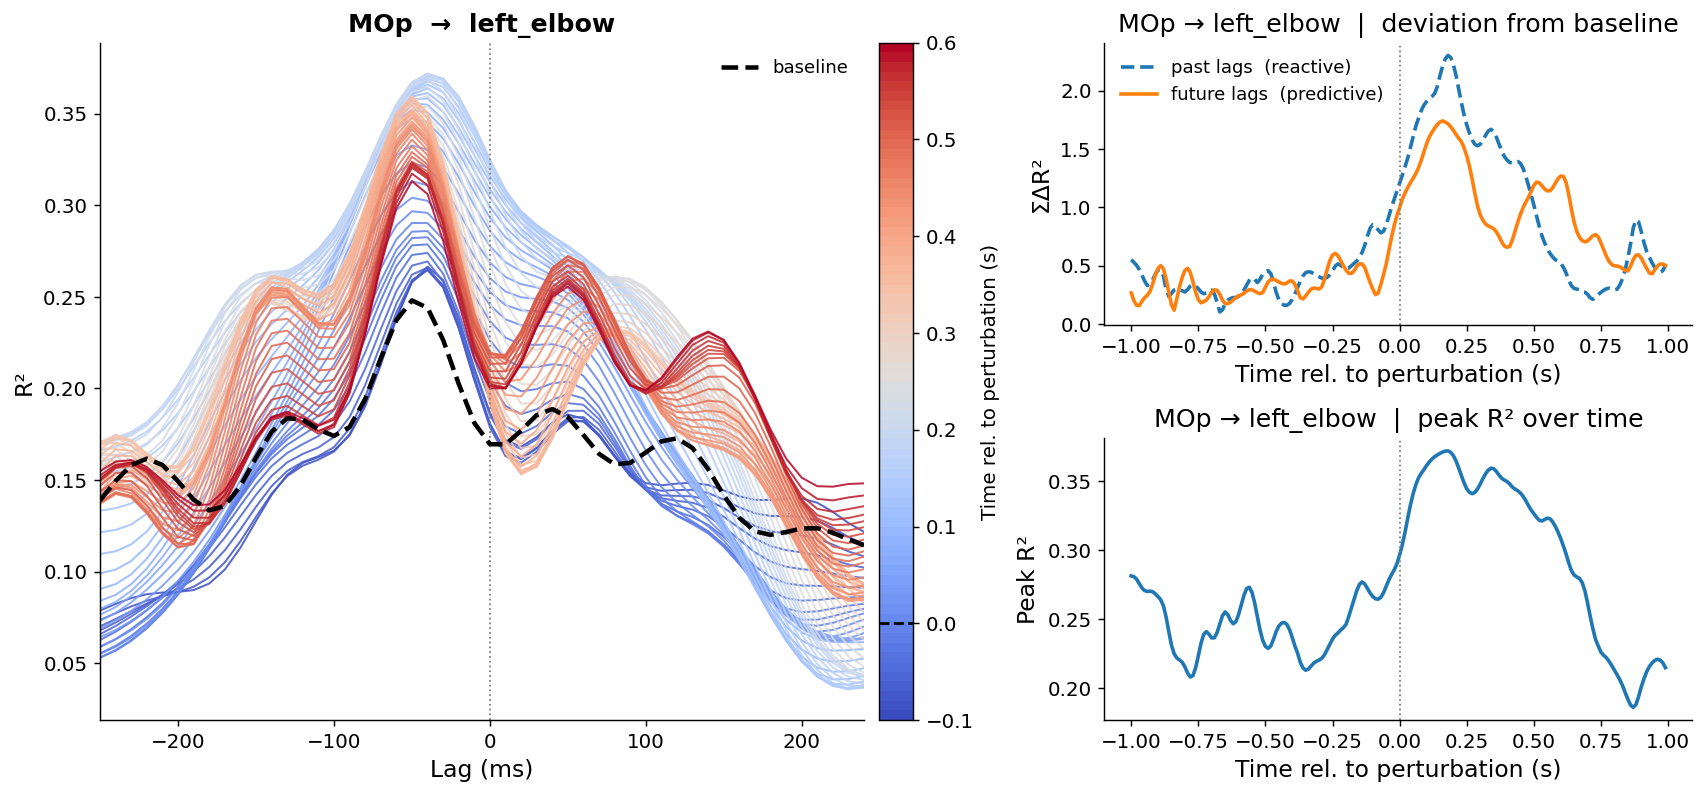

In [21]:
## ── Visualisation ────────────────────────────────────────────────────────────
# Time windows (seconds, relative to perturbation onset)
BASELINE_S  = (-1.0, -0.5)   # pre-perturbation baseline
SPAGHETTI_S = (-0.1,  0.6)   # coloured window for spaghetti plot

PRES_RC = {
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         12,
    "axes.labelsize":    13,
    "axes.titlesize":    14,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "figure.dpi":        130,
}

# ── Derived quantities ────────────────────────────────────────────────────────
all_t   = np.array(sorted(results.keys()))
lags_ms = _lags_bins * BIN_SIZE * 1000                      # lag axis in ms
t_0_idx = np.where(_lags_bins == 0)[0][0]                   # index of lag = 0

# Baseline: average R² curve over pre-perturbation bins
bl_mask       = (all_t >= BASELINE_S[0]) & (all_t < BASELINE_S[1])
baseline_mean = np.array([results[t].mean(-1) for t in all_t[bl_mask]]).mean(0)

# Spaghetti time range
sp_mask = (all_t >= SPAGHETTI_S[0]) & (all_t <= SPAGHETTI_S[1])
sp_t    = all_t[sp_mask]

# Past/future deviation from baseline (over all time bins)
def _deviation(curve, baseline):
    return np.sum(np.abs(curve - baseline))

past_dev   = np.array([_deviation(results[t].mean(-1)[:t_0_idx],   baseline_mean[:t_0_idx])   for t in all_t])
future_dev = np.array([_deviation(results[t].mean(-1)[t_0_idx:],   baseline_mean[t_0_idx:])   for t in all_t])
peak_r2    = np.array([results[t].mean(-1).max()                                               for t in all_t])

# ── Figure ────────────────────────────────────────────────────────────────────
_cmap = mpl.colormaps["coolwarm"].resampled(len(sp_t))
_norm = mpl.colors.Normalize(vmin=SPAGHETTI_S[0], vmax=SPAGHETTI_S[1])
_sm   = mpl.cm.ScalarMappable(cmap=_cmap, norm=_norm)

with mpl.rc_context(PRES_RC):
    fig = plt.figure(figsize=(13, 6), constrained_layout=True)
    gs  = mpl.gridspec.GridSpec(nrows=2, ncols=2, figure=fig,
                                width_ratios=[1.3, 1], height_ratios=[1, 1])

    ax_sp  = fig.add_subplot(gs[:, 0])   # spaghetti — spans both rows
    ax_dev = fig.add_subplot(gs[0, 1])   # deviation — top right
    ax_pk  = fig.add_subplot(gs[1, 1])   # peak R²   — bottom right

    # ── Spaghetti (cell 36 style) ─────────────────────────────────────────
    for t_s in sp_t:
        ax_sp.plot(lags_ms, results[t_s].mean(-1), color=_cmap(_norm(t_s)),
                   lw=1.1, alpha=0.85)

    ax_sp.plot(lags_ms, baseline_mean, color='k', lw=2.5, ls='--',
               zorder=10, label='baseline')
    ax_sp.axvline(0, color='gray', lw=1.0, ls=':')
    ax_sp.set_xlabel('Lag (ms)')
    ax_sp.set_ylabel('R²')
    ax_sp.set_xlim(lags_ms[0], lags_ms[-1])
    ax_sp.set_title(f'{AREA}  →  {KEYPOINT}', fontweight='bold')
    ax_sp.legend(frameon=False, fontsize=10)

    cb = fig.colorbar(_sm, ax=ax_sp, pad=0.02)
    cb.set_label('Time rel. to perturbation (s)', fontsize=11)
    cb.ax.axhline(0, color='k', lw=1.5, ls='--')

    # ── Deviation from baseline (cell 27 style) ───────────────────────────
    ax_dev.plot(all_t, past_dev,   ls='--', lw=2, label='past lags  (reactive)')
    ax_dev.plot(all_t, future_dev, ls='-',  lw=2, label='future lags  (predictive)')
    ax_dev.axvline(0, color='gray', lw=1.0, ls=':')
    ax_dev.set_xlabel('Time rel. to perturbation (s)')
    ax_dev.set_ylabel('ΣΔR²')
    ax_dev.set_title(f'{AREA} → {KEYPOINT}  |  deviation from baseline')
    ax_dev.legend(frameon=False, fontsize=10)

    # ── Peak R² over time (cell 27 style) ────────────────────────────────
    ax_pk.plot(all_t, peak_r2, lw=2)
    ax_pk.axvline(0, color='gray', lw=1.0, ls=':')
    ax_pk.set_xlabel('Time rel. to perturbation (s)')
    ax_pk.set_ylabel('Peak R²')
    ax_pk.set_title(f'{AREA} → {KEYPOINT}  |  peak R² over time')

    plt.show()


In [26]:
## ── Sweep: number of PCA components ─────────────────────────────────────────
# --- Shared parameters ---
AREA        = 'MOp'
KEYPOINT    = 'left_elbow'
WINDOW_S    = 0.20
LAGS_S      = np.arange(-0.25, 0.25, 0.02)
TIME_BINS_S = np.arange(-1.0,  1.0,  0.02)
BIN_SIZE    = 0.01

# --- Sweep parameters ---
N_COMP_MIN   = 30
N_COMP_MAX   = 150
N_COMP_STEP  = 20
N_COMP_RANGE = np.arange(N_COMP_MIN, N_COMP_MAX + 1, N_COMP_STEP)

# --- Derived ---
_rel_start, _rel_end = -200, 300
_perturb_bin = -_rel_start
_window_bins = int(round(WINDOW_S / BIN_SIZE))
_lags_bins   = np.round(LAGS_S   / BIN_SIZE).astype(int)
_time_bins   = (np.round(TIME_BINS_S / BIN_SIZE) + _perturb_bin).astype(int)

perturb_td_sw = pyal.restrict_to_interval(df_design_, 'idx_sol_on', rel_start=_rel_start, rel_end=_rel_end)
power_sw      = np.stack(perturb_td_sw[KEYPOINT].values)          # (trials, time, 3)
_val_full     = np.stack(perturb_td_sw[f'{AREA}_rates_pca'].values)  # (trials, time, max_pcs)

cv_sw         = KFold(n_splits=5, shuffle=False)

# results_sweep[n_comp][t_s] -> (n_lags, n_folds) r2_vw array
results_sweep = {}

for n_comp in tqdm(N_COMP_RANGE, desc="n_components"):
    val_nc   = _val_full[:, :, :n_comp]
    alpha_nc = opt_ridge_alpha(
        val_nc.reshape(-1, val_nc.shape[-1]),
        power_sw.reshape(-1, power_sw.shape[-1]),
    )
    model_nc = Ridge(alpha=alpha_nc)

    def _score_lag(t, lag, y):
        val = shift_time_no_wrap(val_nc, lag)
        val = val[:, t:t + _window_bins, :]
        X   = val.reshape(-1, val.shape[-1])
        cv_out = cross_validate(model_nc, X, y, cv=cv_sw, scoring=vw_r2_scorer, n_jobs=1)
        return cv_out["test_score"]

    res_nc = {}
    for t_s, t in zip(TIME_BINS_S, _time_bins):
        y = power_sw[:, t:t + _window_bins, :].reshape(-1, power_sw.shape[-1])
        per_lag = Parallel(n_jobs=-1, prefer="processes")(
            delayed(_score_lag)(t, lag, y) for lag in _lags_bins
        )
        res_nc[t_s] = np.stack(per_lag, axis=0)   # (n_lags, n_folds)

    results_sweep[n_comp] = res_nc
    print(f"  n_comp={n_comp}  alpha={alpha_nc:.3g}")


n_components:  14%|█▍        | 1/7 [02:00<12:02, 120.41s/it]

  n_comp=30  alpha=1.46e+04


n_components:  29%|██▊       | 2/7 [04:10<10:29, 125.86s/it]

  n_comp=50  alpha=1.46e+04


n_components:  43%|████▎     | 3/7 [06:32<08:53, 133.27s/it]

...

  n_comp=110  alpha=1.46e+04


n_components:  86%|████████▌ | 6/7 [14:57<02:41, 161.83s/it]

  n_comp=130  alpha=1.46e+04


n_components: 100%|██████████| 7/7 [18:14<00:00, 156.33s/it]

  n_comp=150  alpha=1.46e+04


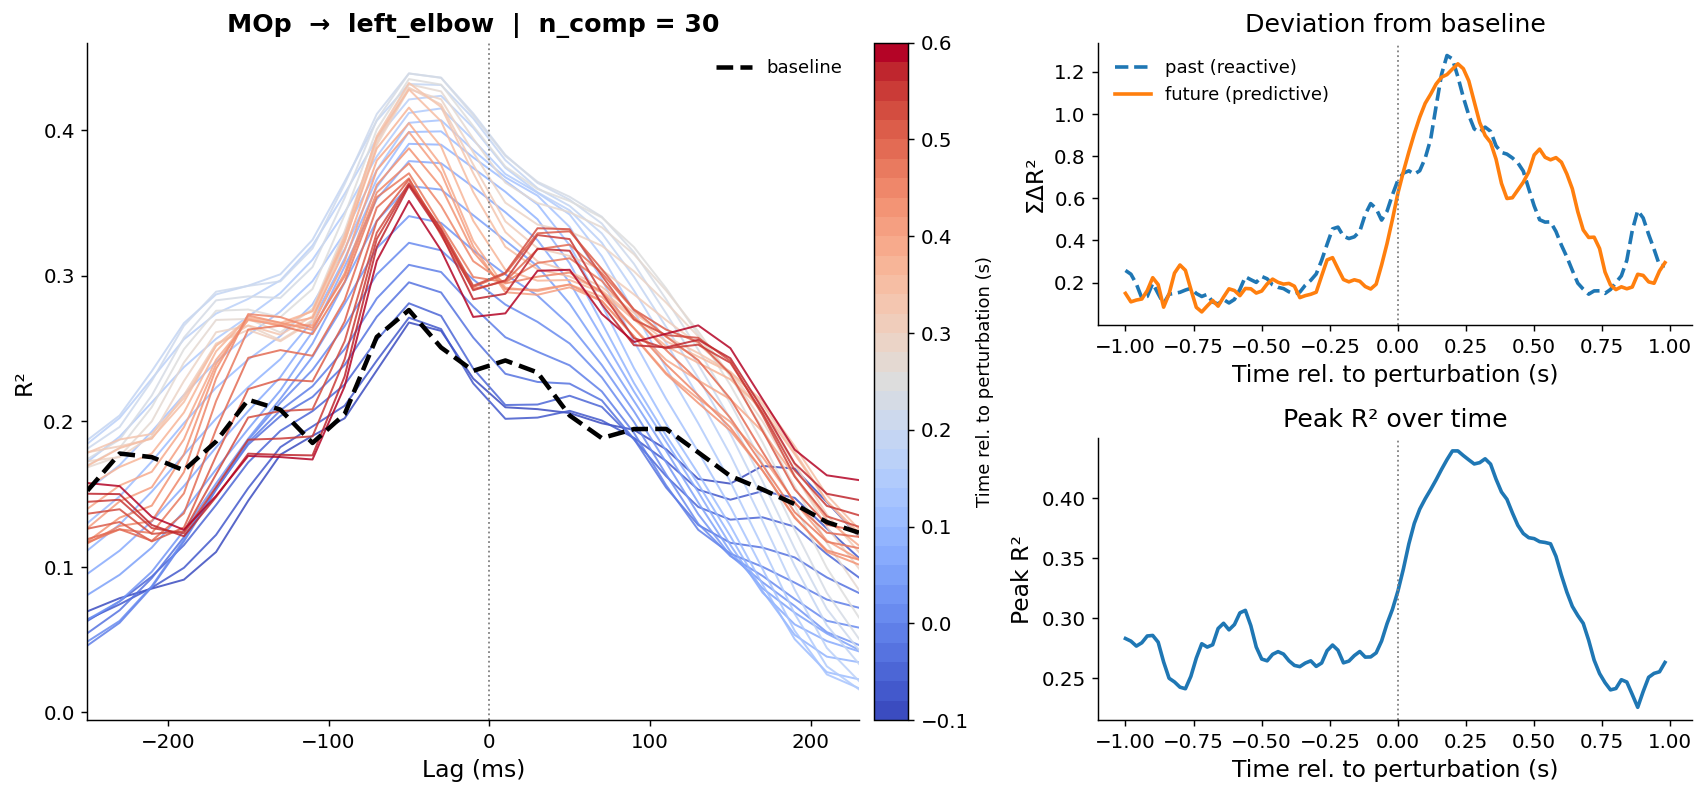

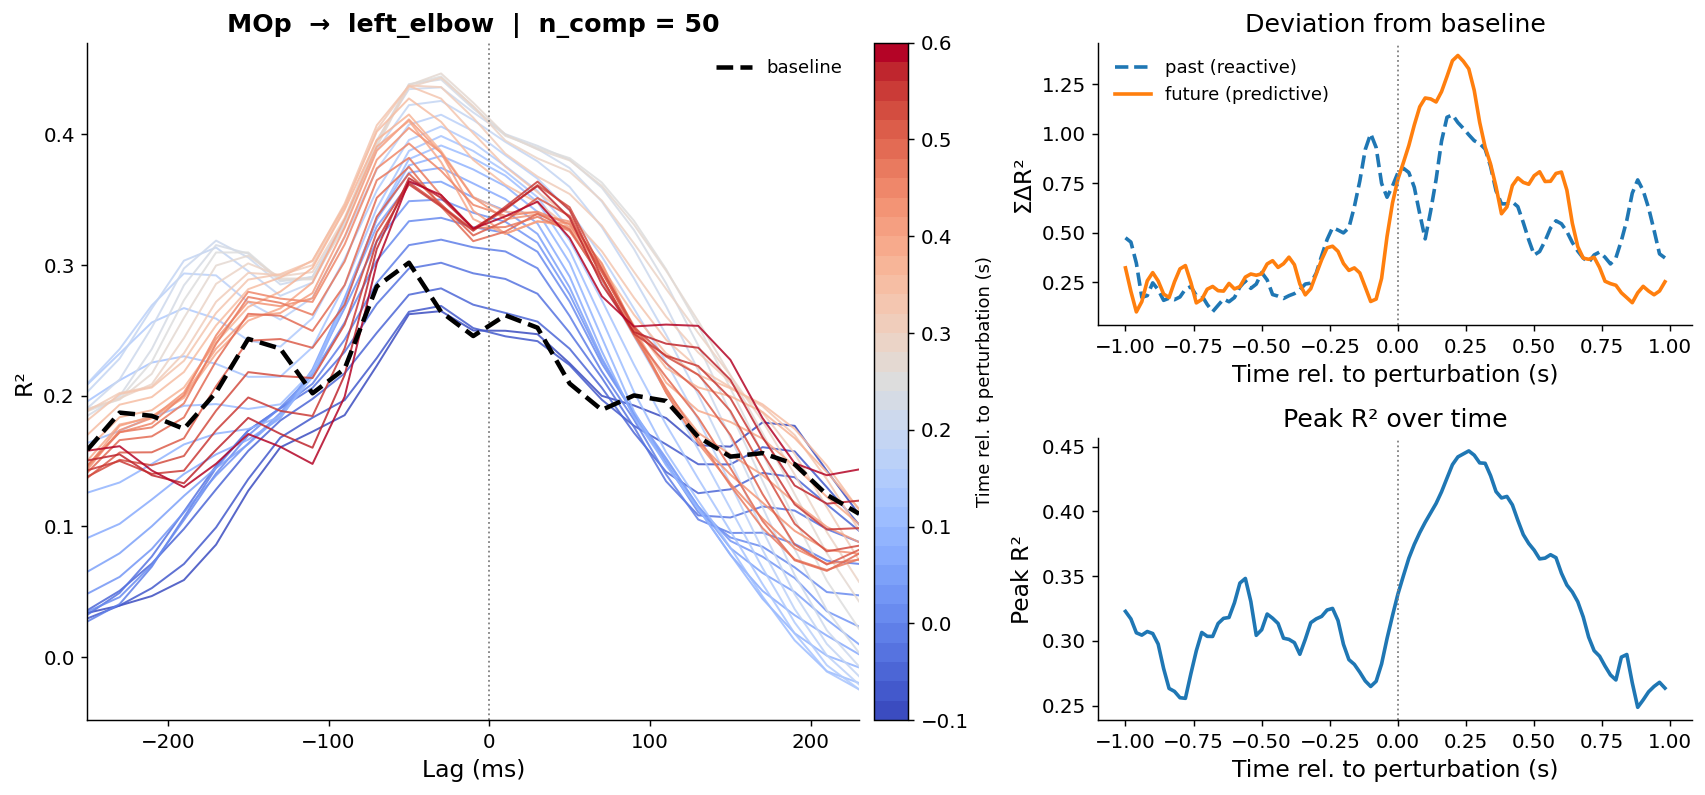

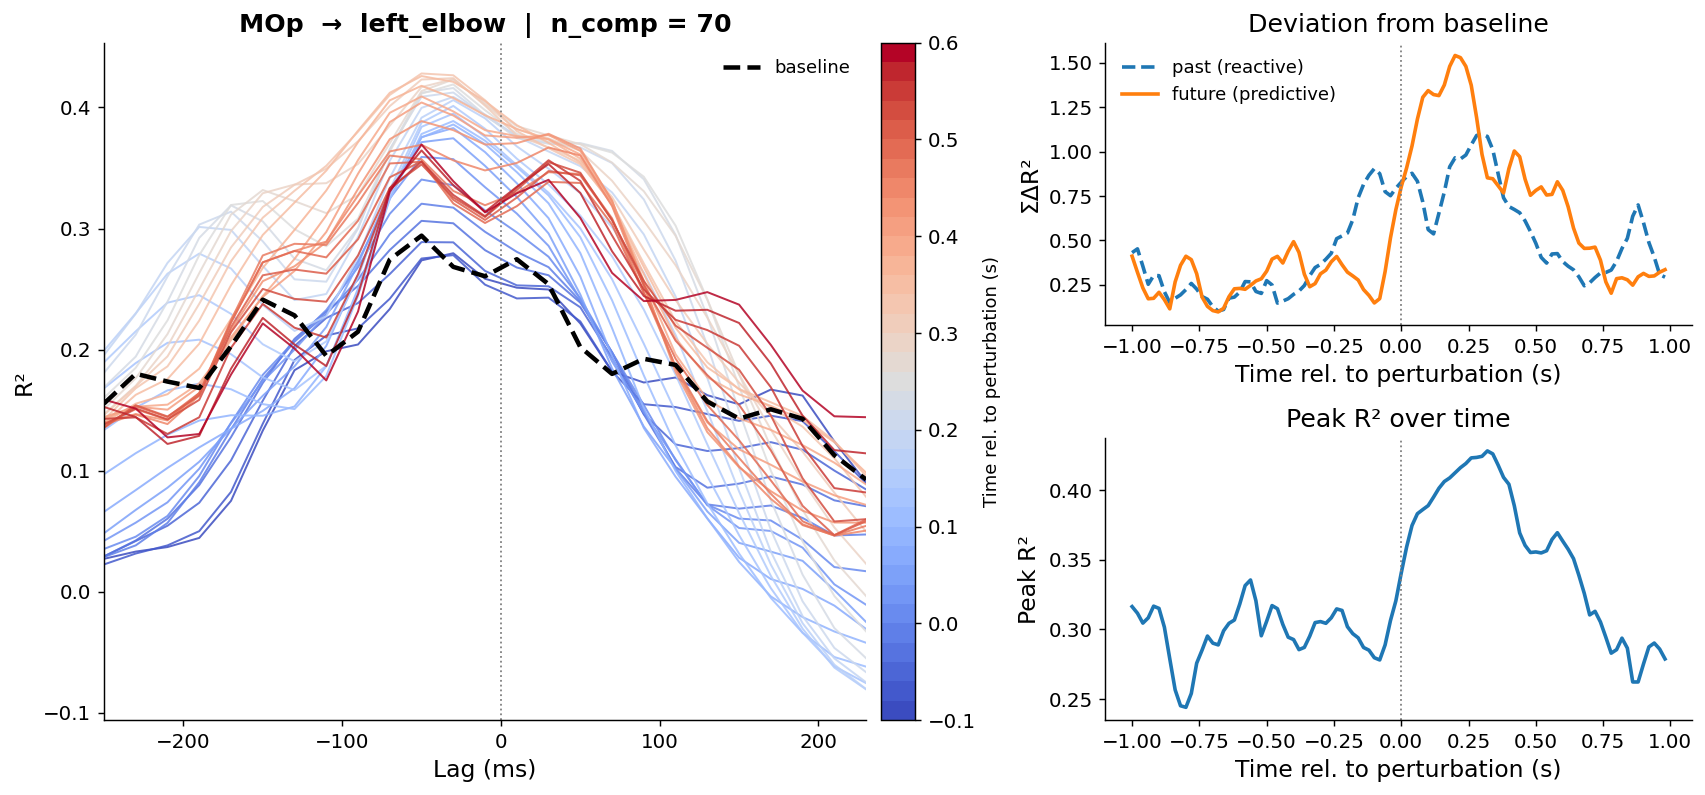

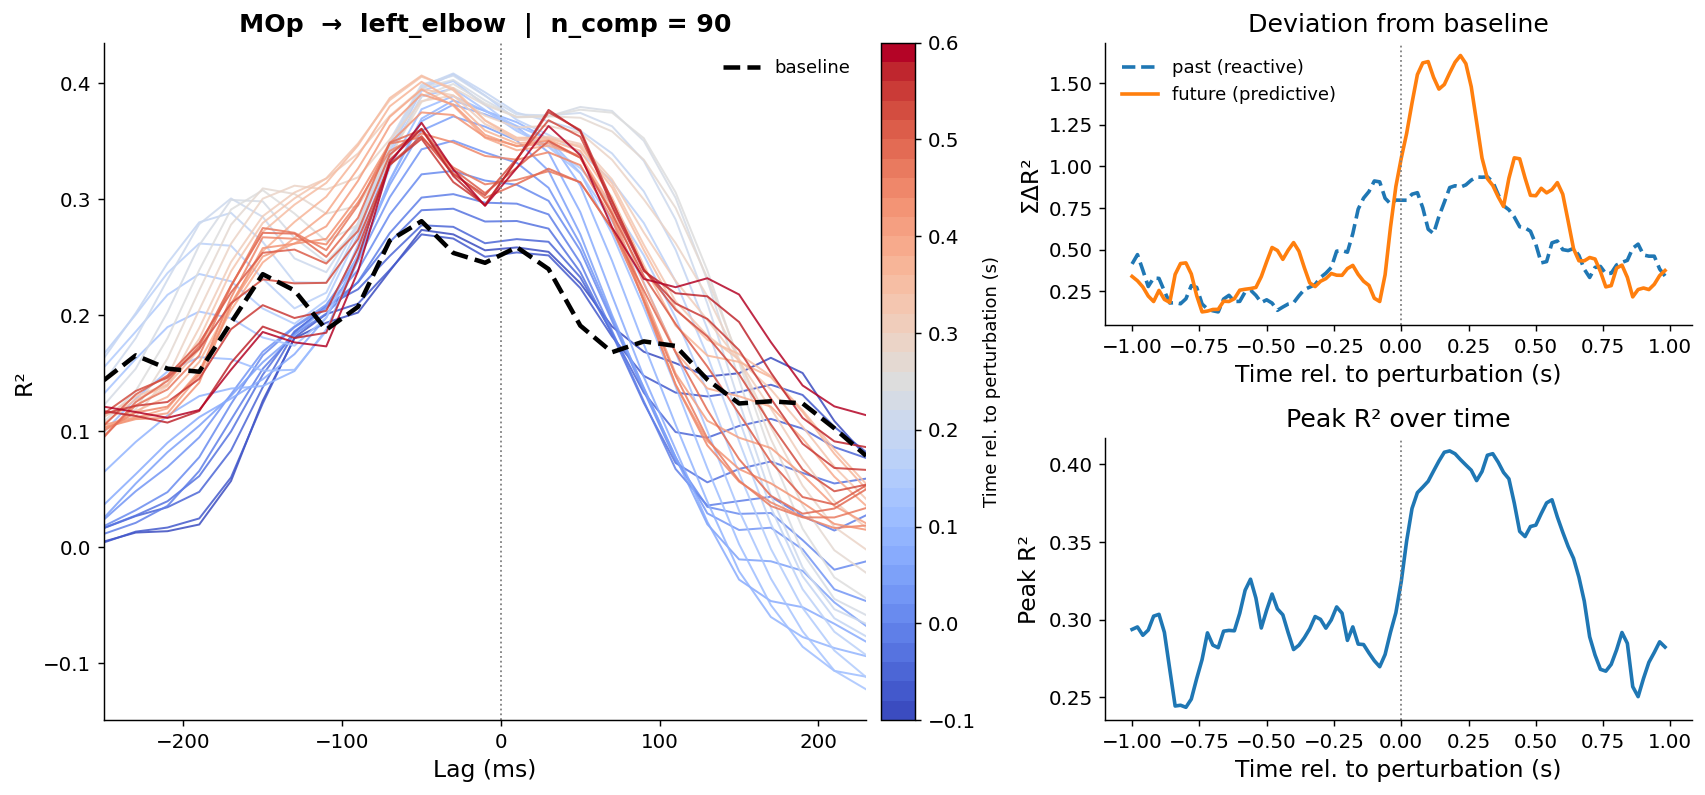

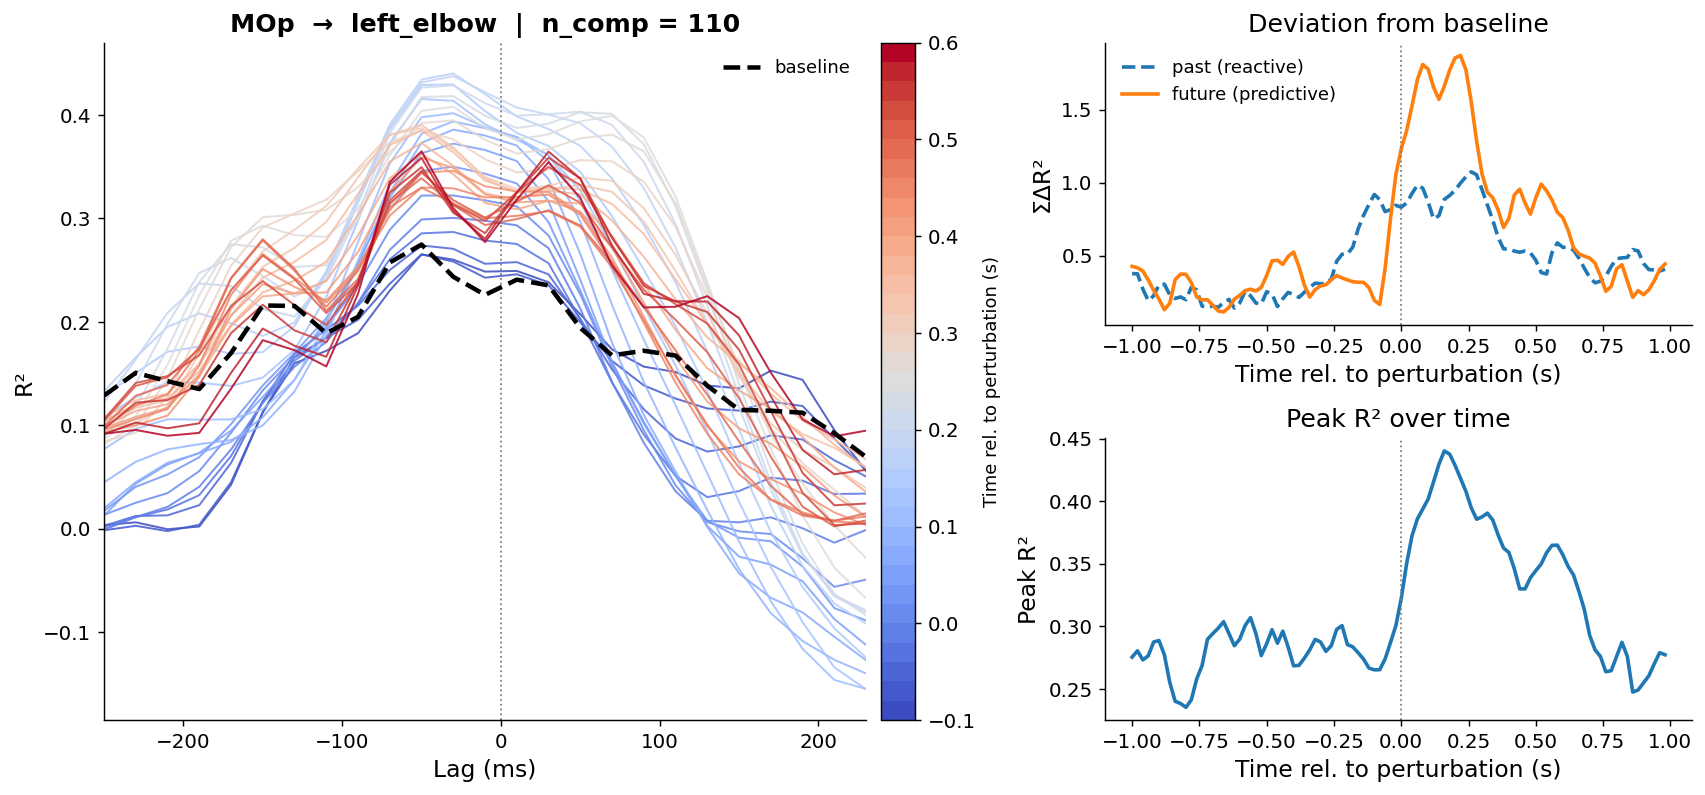

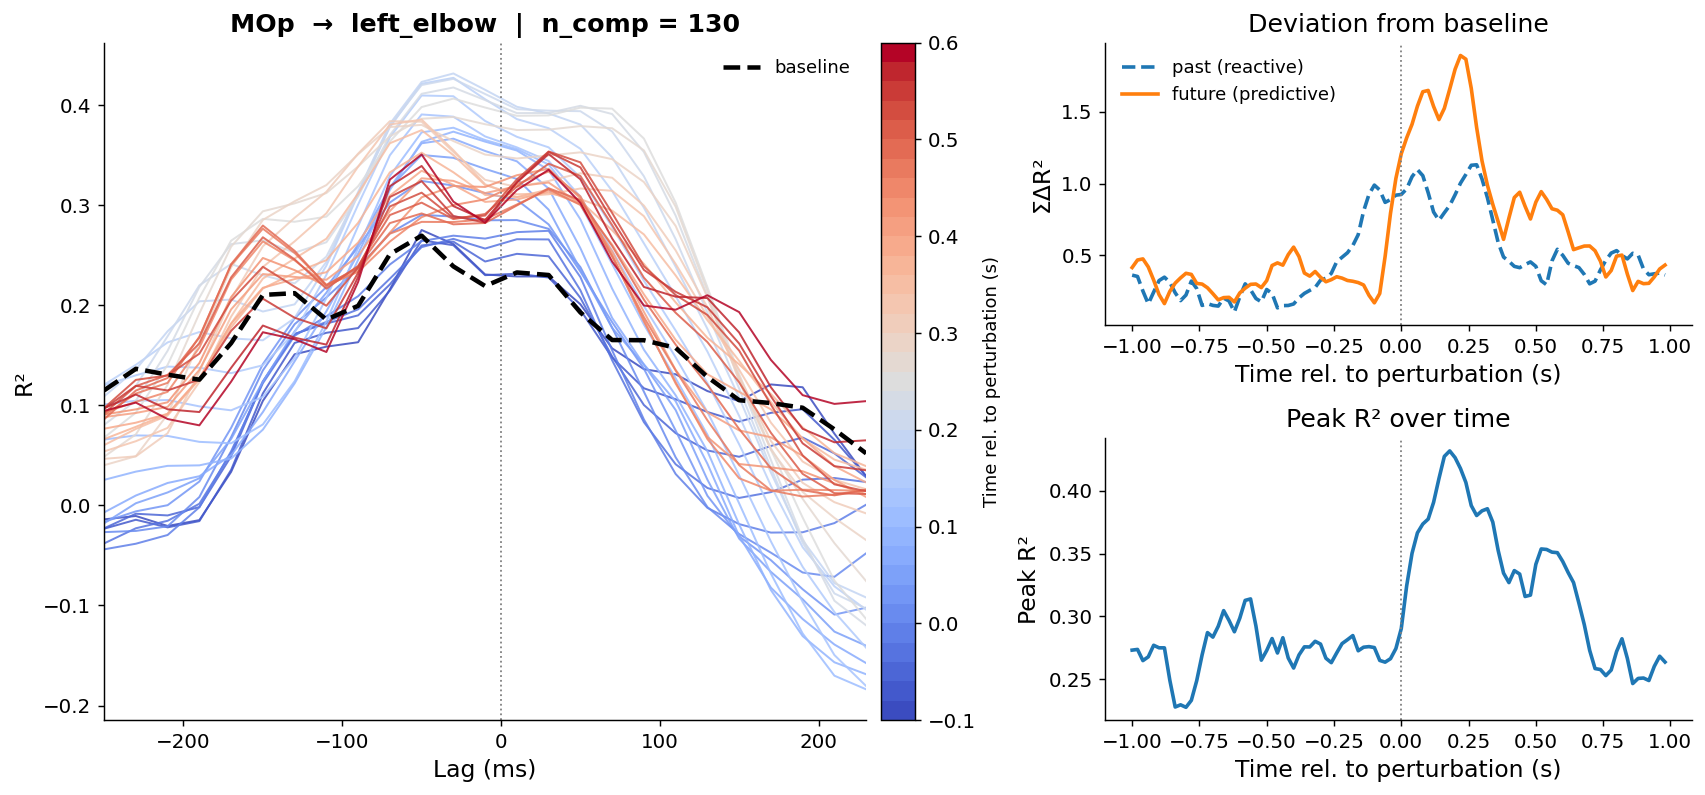

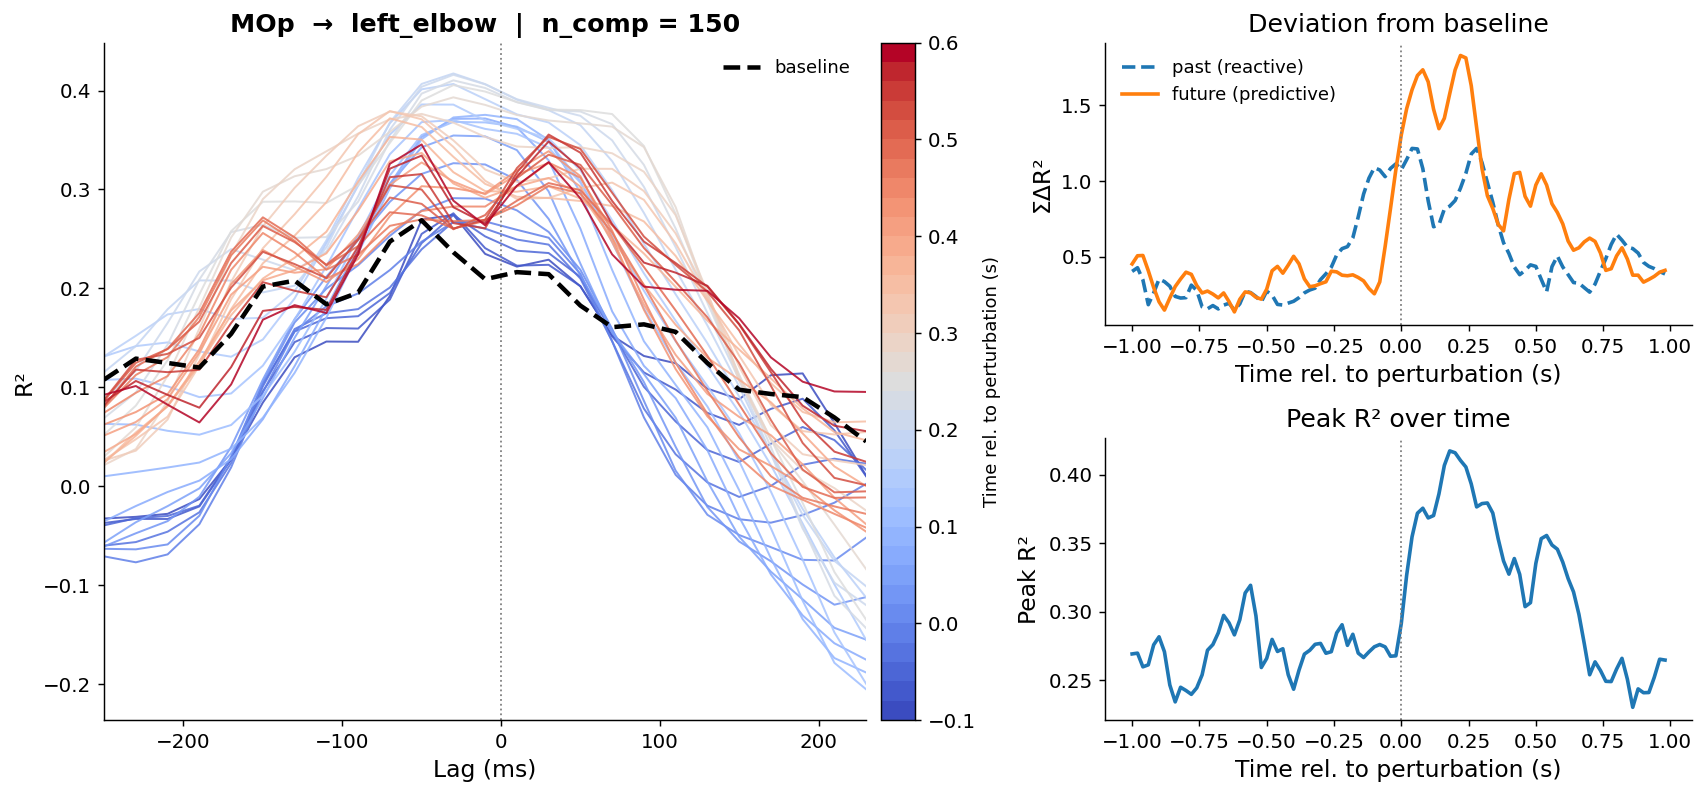

In [31]:
## ── Sweep visualisation: one figure per n_comp ───────────────────────────────
_BASELINE_S  = (-1.0, -0.5)
_SPAGHETTI_S = (-0.1,  0.6)

_lags_ms_sw = _lags_bins * BIN_SIZE * 1000
_t0_sw      = int(np.argmin(np.abs(_lags_bins)))   # index of lag closest to 0

for n_comp, res in results_sweep.items():
    _all_t = np.array(sorted(res.keys()))

    _bl_mask      = (_all_t >= _BASELINE_S[0]) & (_all_t < _BASELINE_S[1])
    _baseline     = np.array([res[t].mean(-1) for t in _all_t[_bl_mask]]).mean(0)

    _sp_mask = (_all_t >= _SPAGHETTI_S[0]) & (_all_t <= _SPAGHETTI_S[1])
    _sp_t    = _all_t[_sp_mask]

    _past_dev   = np.array([np.sum(np.abs(res[t].mean(-1)[:_t0_sw] - _baseline[:_t0_sw])) for t in _all_t])
    _future_dev = np.array([np.sum(np.abs(res[t].mean(-1)[_t0_sw:] - _baseline[_t0_sw:])) for t in _all_t])
    _peak_r2    = np.array([res[t].mean(-1).max()                                          for t in _all_t])

    _cmap = mpl.colormaps["coolwarm"].resampled(len(_sp_t))
    _norm = mpl.colors.Normalize(vmin=_SPAGHETTI_S[0], vmax=_SPAGHETTI_S[1])
    _sm   = mpl.cm.ScalarMappable(cmap=_cmap, norm=_norm)

    with mpl.rc_context(PRES_RC):
        fig = plt.figure(figsize=(13, 6), constrained_layout=True)
        gs  = mpl.gridspec.GridSpec(2, 2, figure=fig,
                                    width_ratios=[1.3, 1], height_ratios=[1, 1])
        ax_sp  = fig.add_subplot(gs[:, 0])
        ax_dev = fig.add_subplot(gs[0, 1])
        ax_pk  = fig.add_subplot(gs[1, 1])

        for t_s in _sp_t:
            ax_sp.plot(_lags_ms_sw, res[t_s].mean(-1),
                       color=_cmap(_norm(t_s)), lw=1.1, alpha=0.85)
        ax_sp.plot(_lags_ms_sw, _baseline, color='k', lw=2.5, ls='--',
                   zorder=10, label='baseline')
        ax_sp.axvline(0, color='gray', lw=1.0, ls=':')
        ax_sp.set_xlabel('Lag (ms)')
        ax_sp.set_ylabel('R²')
        ax_sp.set_xlim(_lags_ms_sw[0], _lags_ms_sw[-1])
        ax_sp.set_title(f'{AREA}  →  {KEYPOINT}  |  n_comp = {n_comp}', fontweight='bold')
        ax_sp.legend(frameon=False, fontsize=10)
        fig.colorbar(_sm, ax=ax_sp, pad=0.02).set_label('Time rel. to perturbation (s)', fontsize=10)

        ax_dev.plot(_all_t, _past_dev,   ls='--', lw=2, label='past (reactive)')
        ax_dev.plot(_all_t, _future_dev, ls='-',  lw=2, label='future (predictive)')
        ax_dev.axvline(0, color='gray', lw=1.0, ls=':')
        ax_dev.set_xlabel('Time rel. to perturbation (s)')
        ax_dev.set_ylabel('ΣΔR²')
        ax_dev.set_title('Deviation from baseline')
        ax_dev.legend(frameon=False, fontsize=10)

        ax_pk.plot(_all_t, _peak_r2, lw=2)
        ax_pk.axvline(0, color='gray', lw=1.0, ls=':')
        ax_pk.set_xlabel('Time rel. to perturbation (s)')
        ax_pk.set_ylabel('Peak R²')
        ax_pk.set_title('Peak R² over time')

        plt.show()


In [37]:
## ── Heatmap: R² at specific lags vs (time × n_components) ───────────────────
QUERY_LAGS_MS = [0, 50, -50]   # lags of interest in ms

n_comps  = np.array(sorted(results_sweep.keys()))
all_t_sw = np.array(sorted(next(iter(results_sweep.values())).keys()))

# _lags_bins / BIN_SIZE * 1000 = lags in ms (from cell 12)
_lags_ms_sw = _lags_bins * BIN_SIZE * 1000

with mpl.rc_context(PRES_RC):
    fig, axes = plt.subplots(1, len(QUERY_LAGS_MS),
                             figsize=(5.5 * len(QUERY_LAGS_MS), 4.5),
                             constrained_layout=True)

    # shared colour scale across all panels
    vmin, vmax = np.inf, -np.inf
    heatmaps = {}
    for lag_ms in QUERY_LAGS_MS:
        lag_idx = int(np.argmin(np.abs(_lags_ms_sw - lag_ms)))
        mat = np.array([
            [results_sweep[nc][t].mean(-1)[lag_idx] for t in all_t_sw]
            for nc in n_comps
        ])                          # (n_comps, n_times)
        heatmaps[lag_ms] = mat
        vmin = min(vmin, mat.min())
        vmax = max(vmax, mat.max())

    for ax, lag_ms in zip(axes, QUERY_LAGS_MS):
        mat = heatmaps[lag_ms]
        actual_lag = _lags_ms_sw[int(np.argmin(np.abs(_lags_ms_sw - lag_ms)))]

        im = ax.imshow(
            mat,
            aspect='auto',
            origin='lower',
            extent=[all_t_sw[0], all_t_sw[-1], n_comps[0], n_comps[-1]],
            vmin=vmin, vmax=vmax,
            cmap='viridis',
        )
        ax.axvline(0, color='w', lw=1.2, ls='--')
        ax.set_xlabel('Time rel. to perturbation (s)')
        ax.set_ylabel('# PCA components')
        ax.set_title(f'Lag = {actual_lag:+.0f} ms', fontweight='bold')

    fig.colorbar(im, ax=axes.tolist(), label='R²  (CV mean, variance-weighted)',
                 shrink=0.8)
    fig.suptitle(f'{AREA}  →  {KEYPOINT}  |  R² at fixed lags', fontweight='bold')
    plt.show()


NameError: name 'results_sweep' is not defined

## Noise control

In [18]:
## ── Control: noise-replacement sweep ─────────────────────────────────────────
# For each n_comp in N_COMP_RANGE, keep the top N_REAL_COMP real PCs and replace
# PCs [N_REAL_COMP : n_comp] with Gaussian noise matched to the variance of the
# corresponding actual PCs.
#
# Interpretation:
#   - If future > past asymmetry grows with n_comp even with noise → artifact
#     (dimensionality inflation / residual autocorrelation exploited by Ridge).
#   - If asymmetry only grows for real PCs → the content of those dimensions matters.

# --- Parameters (self-contained) ---
AREA          = 'MOp'
KEYPOINT      = 'left_elbow'
WINDOW_S      = 0.20
LAGS_S        = np.arange(-0.25, 0.25, 0.02)
TIME_BINS_S   = np.arange(-1.0,  1.0,  0.02)
BIN_SIZE      = 0.01
N_REAL_COMP   = 30                          # real PCs to keep; noise replaces everything above
N_COMP_RANGE  = np.arange(30, 151, 20)     # total feature count per sweep step
NOISE_SEED    = 0                           # for reproducibility

# --- Derived ---
_rel_start_n, _rel_end_n = -200, 300
_perturb_bin_n = -_rel_start_n
_window_bins_n = int(round(WINDOW_S / BIN_SIZE))
_lags_bins_n   = np.round(LAGS_S   / BIN_SIZE).astype(int)
_time_bins_n   = (np.round(TIME_BINS_S / BIN_SIZE) + _perturb_bin_n).astype(int)

perturb_td_n = pyal.restrict_to_interval(df_design_, 'idx_sol_on',
                                          rel_start=_rel_start_n, rel_end=_rel_end_n)
power_n      = np.stack(perturb_td_n[KEYPOINT].values)                      # (trials, T, 3)
_val_full_n  = np.stack(perturb_td_n[f'{AREA}_rates_pca'].values)           # (trials, T, max_pcs)

cv_n = KFold(n_splits=5, shuffle=False)
rng  = np.random.default_rng(NOISE_SEED)

# Per-PC std so each noise column has matched variance
_pc_stds_n = _val_full_n.reshape(-1, _val_full_n.shape[-1]).std(0)          # (max_pcs,)

def _make_noise_val(n_comp, rng_):
    """Real PCs 0:N_REAL_COMP concatenated with matched-variance noise columns."""
    real_part = _val_full_n[:, :, :N_REAL_COMP]
    n_noise   = max(0, n_comp - N_REAL_COMP)
    if n_noise == 0:
        return real_part.copy()
    noise_stds = _pc_stds_n[N_REAL_COMP : N_REAL_COMP + n_noise]
    noise = rng_.standard_normal((*real_part.shape[:2], n_noise)) * noise_stds
    return np.concatenate([real_part, noise], axis=-1)

results_noise_sweep = {}

for n_comp in tqdm(N_COMP_RANGE, desc="n_components (noise control)"):
    val_nc   = _make_noise_val(n_comp, rng)          # new noise draw each iteration
    alpha_nc = opt_ridge_alpha(
        val_nc.reshape(-1, val_nc.shape[-1]),
        power_n.reshape(-1, power_n.shape[-1]),
    )
    model_nc = Ridge(alpha=alpha_nc)

    def _score_lag_n(t, lag, y):
        val = shift_time_no_wrap(val_nc, lag)
        val = val[:, t:t + _window_bins_n, :]
        X   = val.reshape(-1, val.shape[-1])
        cv_out = cross_validate(model_nc, X, y, cv=cv_n, scoring=vw_r2_scorer, n_jobs=1)
        return cv_out["test_score"]

    res_nc = {}
    for t_s, t in zip(TIME_BINS_S, _time_bins_n):
        y = power_n[:, t:t + _window_bins_n, :].reshape(-1, power_n.shape[-1])
        per_lag = Parallel(n_jobs=-1, prefer="processes")(
            delayed(_score_lag_n)(t, lag, y) for lag in _lags_bins_n
        )
        res_nc[t_s] = np.stack(per_lag, axis=0)   # (n_lags, n_folds)

    results_noise_sweep[n_comp] = res_nc
    n_noise = max(0, n_comp - N_REAL_COMP)
    print(f"  n_comp={n_comp}  (real={min(n_comp, N_REAL_COMP)}, noise={n_noise})  alpha={alpha_nc:.3g}")


n_components (noise control):  14%|█▍        | 1/7 [01:59<11:55, 119.19s/it]

  n_comp=30  (real=30, noise=0)  alpha=1.46e+04


n_components (noise control):  29%|██▊       | 2/7 [04:10<10:33, 126.61s/it]

  n_comp=50  (real=30, noise=20)  alpha=3.73e+04


n_components (noise control):  43%|████▎     | 3/7 [06:36<09:00, 135.13s/it]

...

  n_comp=110  (real=30, noise=80)  alpha=1.53e+05


n_components (noise control):  86%|████████▌ | 6/7 [15:16<02:46, 166.26s/it]

  n_comp=130  (real=30, noise=100)  alpha=1.53e+05


n_components (noise control): 100%|██████████| 7/7 [18:28<00:00, 158.31s/it]

  n_comp=150  (real=30, noise=120)  alpha=2.44e+05


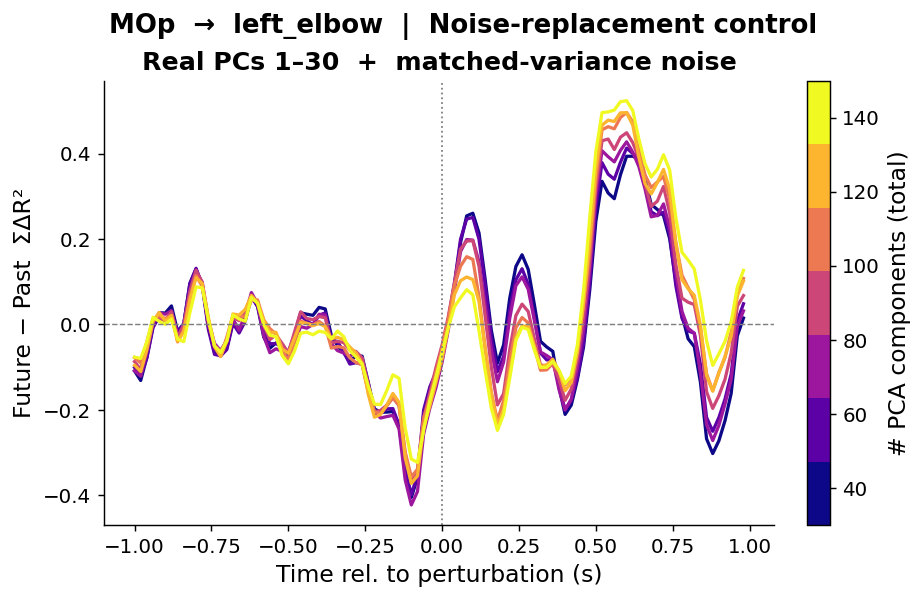

In [21]:
## ── Noise control visualisation: future−past asymmetry ───────────────────────
_BASELINE_S_NC = (-1.0, -0.5)
PRES_RC = {
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         12,
    "axes.labelsize":    13,
    "axes.titlesize":    14,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "figure.dpi":        130,
}
n_comps_noise = np.array(sorted(results_noise_sweep.keys()))
_all_t_n2     = np.array(sorted(next(iter(results_noise_sweep.values())).keys()))
_t0_n         = int(np.argmin(np.abs(_lags_bins_n)))   # from noise sweep cell

def _fp_gap_curve(res_dict, nc, all_t, bl_s, t0):
    """Future − past ΣΔR² over time for one (res_dict, n_comp)."""
    res = res_dict[nc]
    bl_mask  = (all_t >= bl_s[0]) & (all_t < bl_s[1])
    baseline = np.array([res[t].mean(-1) for t in all_t[bl_mask]]).mean(0)
    future   = np.array([np.sum(np.abs(res[t].mean(-1)[t0:] - baseline[t0:])) for t in all_t])
    past     = np.array([np.sum(np.abs(res[t].mean(-1)[:t0] - baseline[:t0])) for t in all_t])
    return future - past

_cmap_nc = mpl.colormaps['plasma'].resampled(len(n_comps_noise))
_norm_nc = mpl.colors.Normalize(vmin=n_comps_noise[0], vmax=n_comps_noise[-1])

with mpl.rc_context(PRES_RC):
    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)

    for nc in n_comps_noise:
        gap = _fp_gap_curve(results_noise_sweep, nc, _all_t_n2, _BASELINE_S_NC, _t0_n)
        ax.plot(_all_t_n2, gap, color=_cmap_nc(_norm_nc(nc)), lw=1.8)

    ax.axvline(0, color='gray', lw=1.0, ls=':')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel('Time rel. to perturbation (s)')
    ax.set_ylabel('Future − Past  ΣΔR²')
    ax.set_title(f'Real PCs 1–{N_REAL_COMP}  +  matched-variance noise', fontweight='bold')

    sm = mpl.cm.ScalarMappable(cmap=_cmap_nc, norm=_norm_nc)
    fig.colorbar(sm, ax=ax, label='# PCA components (total)')
    fig.suptitle(f'{AREA}  →  {KEYPOINT}  |  Noise-replacement control', fontweight='bold')
    plt.show()


In [23]:
## ── Noise control: two fixed conditions ──────────────────────────────────────
# Condition A – "noise":  30 real PCs + matched-variance noise up to max PCs
# Condition B – "real":   all real PCs
# Both decoded against left_elbow.

# --- Parameters ---
AREA        = 'MOp'
KEYPOINT    = 'left_elbow'
WINDOW_S    = 0.20
LAGS_S      = np.arange(-0.25, 0.25, 0.02)
TIME_BINS_S = np.arange(-1.0,  1.0,  0.02)
BIN_SIZE    = 0.01
N_REAL_COMP = 30      # real PCs kept in the noise condition
NOISE_SEED  = 0

# --- Derived ---
_rel_start_2, _rel_end_2 = -200, 300
_perturb_bin_2 = -_rel_start_2
_window_bins_2 = int(round(WINDOW_S / BIN_SIZE))
_lags_bins_2   = np.round(LAGS_S   / BIN_SIZE).astype(int)
_time_bins_2   = (np.round(TIME_BINS_S / BIN_SIZE) + _perturb_bin_2).astype(int)

perturb_td_2 = pyal.restrict_to_interval(df_design_, 'idx_sol_on',
                                          rel_start=_rel_start_2, rel_end=_rel_end_2)
power_2      = np.stack(perturb_td_2[KEYPOINT].values)               # (trials, T, 3)
val_full_2   = np.stack(perturb_td_2[f'{AREA}_rates_pca'].values)    # (trials, T, max_pcs)
MAX_COMP     = val_full_2.shape[-1]

cv_2 = KFold(n_splits=5, shuffle=False)

# Noise array: 30 real PCs + matched-variance noise up to MAX_COMP
_pc_stds_2 = val_full_2.reshape(-1, MAX_COMP).std(0)
rng_2      = np.random.default_rng(NOISE_SEED)
_noise_cols = rng_2.standard_normal((*val_full_2.shape[:2], MAX_COMP - N_REAL_COMP))
_noise_cols *= _pc_stds_2[N_REAL_COMP:]
val_noise_2 = np.concatenate([val_full_2[:, :, :N_REAL_COMP], _noise_cols], axis=-1)
val_real_2  = val_full_2   # all real PCs

print(f"MAX_COMP = {MAX_COMP}  |  noise condition: {N_REAL_COMP} real + {MAX_COMP - N_REAL_COMP} noise")

def _run_condition(val_arr, label):
    alpha_ = opt_ridge_alpha(
        val_arr.reshape(-1, val_arr.shape[-1]),
        power_2.reshape(-1, power_2.shape[-1]),
    )
    print(f"  [{label}]  alpha = {alpha_:.3g}")
    model_ = Ridge(alpha=alpha_)

    def _score(t, lag, y):
        v = shift_time_no_wrap(val_arr, lag)
        v = v[:, t:t + _window_bins_2, :]
        X = v.reshape(-1, v.shape[-1])
        return cross_validate(model_, X, y, cv=cv_2, scoring=vw_r2_scorer, n_jobs=1)["test_score"]

    res = {}
    for t_s, t in tqdm(zip(TIME_BINS_S, _time_bins_2), total=len(_time_bins_2), desc=label):
        y = power_2[:, t:t + _window_bins_2, :].reshape(-1, power_2.shape[-1])
        per_lag = Parallel(n_jobs=-1, prefer="processes")(
            delayed(_score)(t, lag, y) for lag in _lags_bins_2
        )
        res[t_s] = np.stack(per_lag, axis=0)   # (n_lags, n_folds)
    return res

results_noise_2 = _run_condition(val_noise_2, f"noise ({N_REAL_COMP} real + {MAX_COMP-N_REAL_COMP} noise)")
results_real_2  = _run_condition(val_real_2,  f"real  ({MAX_COMP} PCs)")


MAX_COMP = 178  |  noise condition: 30 real + 148 noise
  [noise (30 real + 148 noise)]  alpha = 2.44e+05


noise (30 real + 148 noise): 100%|██████████| 100/100 [01:55<00:00,  1.15s/it]


  [real  (178 PCs)]  alpha = 2.33e+04


real  (178 PCs): 100%|██████████| 100/100 [01:59<00:00,  1.19s/it]


In [34]:
## ── Condition C: 30 real PCs only ────────────────────────────────────────────
val_30_2     = val_full_2[:, :, :N_REAL_COMP]   # (trials, T, 30)
results_30_2 = _run_condition(val_30_2, f"30 real PCs only")


  [30 real PCs only]  alpha = 1.46e+04


30 real PCs only: 100%|██████████| 100/100 [00:28<00:00,  3.54it/s]


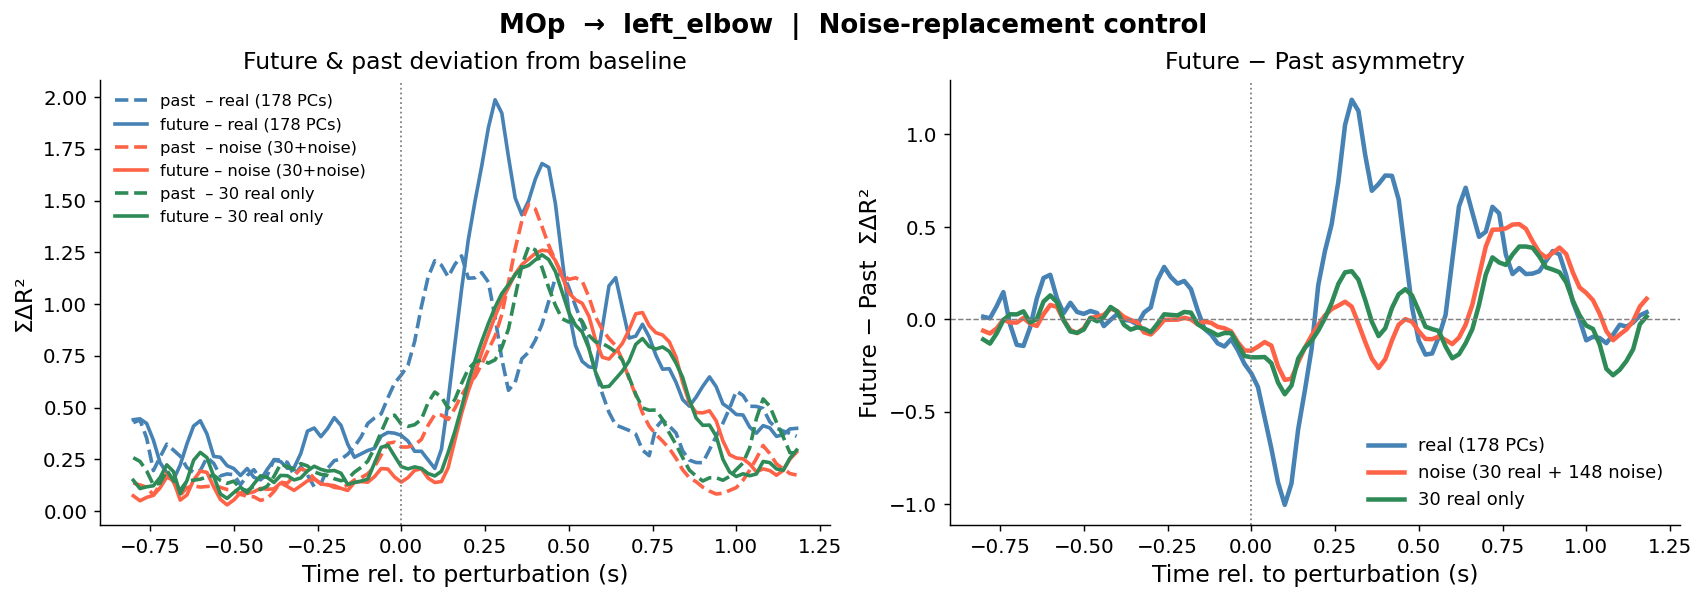

In [36]:
## ── Noise control viz: future − past deviation from baseline ─────────────────
_BASELINE_S_2 = (-1.0, -0.5)

_all_t_2    = np.array(sorted(results_noise_2.keys()))
_t_center_2 = _all_t_2 + WINDOW_S   # shift to end of window (−0.20 s)
_t0_2       = int(np.argmin(np.abs(_lags_bins_2)))

def _fp_deviation(res, all_t, bl_s, t0):
    """Returns (future_dev, past_dev, future-past gap) arrays over time."""
    bl_mask  = (all_t >= bl_s[0]) & (all_t < bl_s[1])
    baseline = np.array([res[t].mean(-1) for t in all_t[bl_mask]]).mean(0)
    future   = np.array([np.sum(np.abs(res[t].mean(-1)[t0:] - baseline[t0:])) for t in all_t])
    past     = np.array([np.sum(np.abs(res[t].mean(-1)[:t0] - baseline[:t0])) for t in all_t])
    return future, past, future - past

fut_n,  pas_n,  gap_n  = _fp_deviation(results_noise_2, _all_t_2, _BASELINE_S_2, _t0_2)
fut_r,  pas_r,  gap_r  = _fp_deviation(results_real_2,  _all_t_2, _BASELINE_S_2, _t0_2)
fut_30, pas_30, gap_30 = _fp_deviation(results_30_2,    _all_t_2, _BASELINE_S_2, _t0_2)

PRES_RC_2 = {
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 12, "axes.labelsize": 13, "axes.titlesize": 13,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "figure.dpi": 130,
}

with mpl.rc_context(PRES_RC_2):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True, sharey=False)

    # Left: future and past ΣΔR² separately for each condition
    ax = axes[0]
    ax.plot(_t_center_2, pas_r,   ls='--', lw=2, color='steelblue', label=f'past  – real ({MAX_COMP} PCs)')
    ax.plot(_t_center_2, fut_r,   ls='-',  lw=2, color='steelblue', label=f'future – real ({MAX_COMP} PCs)')
    ax.plot(_t_center_2, pas_n,   ls='--', lw=2, color='tomato',    label=f'past  – noise ({N_REAL_COMP}+noise)')
    ax.plot(_t_center_2, fut_n,   ls='-',  lw=2, color='tomato',    label=f'future – noise ({N_REAL_COMP}+noise)')
    ax.plot(_t_center_2, pas_30,  ls='--', lw=2, color='seagreen',  label=f'past  – {N_REAL_COMP} real only')
    ax.plot(_t_center_2, fut_30,  ls='-',  lw=2, color='seagreen',  label=f'future – {N_REAL_COMP} real only')
    ax.axvline(0, color='gray', lw=1.0, ls=':')
    ax.set_xlabel('Time rel. to perturbation (s)')
    ax.set_ylabel('ΣΔR²')
    ax.set_title('Future & past deviation from baseline')
    ax.legend(frameon=False, fontsize=9)

    # Right: future − past gap
    ax = axes[1]
    ax.plot(_t_center_2, gap_r,  lw=2.5, color='steelblue', label=f'real ({MAX_COMP} PCs)')
    ax.plot(_t_center_2, gap_n,  lw=2.5, color='tomato',    label=f'noise ({N_REAL_COMP} real + {MAX_COMP-N_REAL_COMP} noise)')
    ax.plot(_t_center_2, gap_30, lw=2.5, color='seagreen',  label=f'{N_REAL_COMP} real only')
    ax.axvline(0, color='gray', lw=1.0, ls=':')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel('Time rel. to perturbation (s)')
    ax.set_ylabel('Future − Past  ΣΔR²')
    ax.set_title('Future − Past asymmetry')
    ax.legend(frameon=False, fontsize=10)

    fig.suptitle(f'{AREA}  →  {KEYPOINT}  |  Noise-replacement control', fontweight='bold')
    plt.show()


In [38]:
## ── Dual sweep: real PCs vs noise PCs (30 to 170, step 20) ──────────────────
# For each n_comp value:
#   "real"  condition  → first n_comp real PCs
#   "noise" condition  → N_REAL_COMP real PCs + (n_comp - N_REAL_COMP) noise PCs

# --- Parameters ---
AREA          = 'MOp'
KEYPOINT      = 'left_elbow'
WINDOW_S      = 0.20
LAGS_S        = np.arange(-0.25, 0.25, 0.02)
TIME_BINS_S   = np.arange(-1.0,  1.0,  0.02)
BIN_SIZE      = 0.01
N_REAL_COMP   = 30
N_COMP_RANGE  = np.arange(30, 171, 20)   # [30, 50, 70, 90, 110, 130, 150, 170]
NOISE_SEED    = 0

# --- Derived ---
_rel_start_ds, _rel_end_ds = -200, 300
_perturb_bin_ds = -_rel_start_ds
_window_bins_ds = int(round(WINDOW_S / BIN_SIZE))
_lags_bins_ds   = np.round(LAGS_S   / BIN_SIZE).astype(int)
_time_bins_ds   = (np.round(TIME_BINS_S / BIN_SIZE) + _perturb_bin_ds).astype(int)

perturb_td_ds = pyal.restrict_to_interval(df_design_, 'idx_sol_on',
                                           rel_start=_rel_start_ds, rel_end=_rel_end_ds)
power_ds    = np.stack(perturb_td_ds[KEYPOINT].values)               # (trials, T, 3)
val_full_ds = np.stack(perturb_td_ds[f'{AREA}_rates_pca'].values)    # (trials, T, max_pcs)

cv_ds = KFold(n_splits=5, shuffle=False)

# Pre-generate all noise columns once (reproducible)
_pc_stds_ds = val_full_ds.reshape(-1, val_full_ds.shape[-1]).std(0)
_rng_ds     = np.random.default_rng(NOISE_SEED)
_n_noise_max = int(N_COMP_RANGE[-1]) - N_REAL_COMP
_all_noise_ds = (_rng_ds.standard_normal((*val_full_ds.shape[:2], _n_noise_max))
                 * _pc_stds_ds[N_REAL_COMP : N_REAL_COMP + _n_noise_max])

results_real_sweep_ds  = {}   # results_real_sweep_ds[n_comp][t_s]  → (n_lags, n_folds)
results_noise_sweep_ds = {}   # results_noise_sweep_ds[n_comp][t_s] → (n_lags, n_folds)

for n_comp in tqdm(N_COMP_RANGE, desc="dual sweep"):
    n_noise = max(0, n_comp - N_REAL_COMP)

    # Build feature arrays for this n_comp
    val_real_nc  = val_full_ds[:, :, :n_comp]
    if n_noise == 0:
        val_noise_nc = val_full_ds[:, :, :N_REAL_COMP].copy()
    else:
        val_noise_nc = np.concatenate(
            [val_full_ds[:, :, :N_REAL_COMP], _all_noise_ds[:, :, :n_noise]], axis=-1
        )

    # Optimise ridge alpha per condition
    alpha_real  = opt_ridge_alpha(val_real_nc.reshape(-1, n_comp),
                                  power_ds.reshape(-1, power_ds.shape[-1]))
    alpha_noise = opt_ridge_alpha(val_noise_nc.reshape(-1, n_comp),
                                  power_ds.reshape(-1, power_ds.shape[-1]))
    model_real  = Ridge(alpha=alpha_real)
    model_noise = Ridge(alpha=alpha_noise)
    print(f"  n_comp={n_comp}  alpha_real={alpha_real:.3g}  alpha_noise={alpha_noise:.3g}")

    # Decode loop (real condition)
    def _score_real_ds(t, lag, y):
        v = shift_time_no_wrap(val_real_nc, lag)
        v = v[:, t:t + _window_bins_ds, :]
        X = v.reshape(-1, v.shape[-1])
        return cross_validate(model_real, X, y, cv=cv_ds, scoring=vw_r2_scorer, n_jobs=1)["test_score"]

    # Decode loop (noise condition)
    def _score_noise_ds(t, lag, y):
        v = shift_time_no_wrap(val_noise_nc, lag)
        v = v[:, t:t + _window_bins_ds, :]
        X = v.reshape(-1, v.shape[-1])
        return cross_validate(model_noise, X, y, cv=cv_ds, scoring=vw_r2_scorer, n_jobs=1)["test_score"]

    res_real_nc  = {}
    res_noise_nc = {}
    for t_s, t in zip(TIME_BINS_S, _time_bins_ds):
        y = power_ds[:, t:t + _window_bins_ds, :].reshape(-1, power_ds.shape[-1])
        per_lag_real  = Parallel(n_jobs=-1, prefer="processes")(
            delayed(_score_real_ds)(t, lag, y) for lag in _lags_bins_ds
        )
        per_lag_noise = Parallel(n_jobs=-1, prefer="processes")(
            delayed(_score_noise_ds)(t, lag, y) for lag in _lags_bins_ds
        )
        res_real_nc[t_s]  = np.stack(per_lag_real,  axis=0)
        res_noise_nc[t_s] = np.stack(per_lag_noise, axis=0)

    results_real_sweep_ds[n_comp]  = res_real_nc
    results_noise_sweep_ds[n_comp] = res_noise_nc


dual sweep:   0%|          | 0/8 [00:00<?, ?it/s]

  n_comp=30  alpha_real=1.46e+04  alpha_noise=1.46e+04


dual sweep:  12%|█▎        | 1/8 [03:55<27:27, 235.37s/it]

  n_comp=50  alpha_real=1.46e+04  alpha_noise=3.73e+04


dual sweep:  25%|██▌       | 2/8 [08:17<25:06, 251.12s/it]

...

dual sweep:  75%|███████▌  | 6/8 [30:19<10:59, 329.92s/it]

  n_comp=150  alpha_real=1.46e+04  alpha_noise=2.44e+05


dual sweep:  88%|████████▊ | 7/8 [36:50<05:49, 349.86s/it]

  n_comp=170  alpha_real=2.33e+04  alpha_noise=2.44e+05


dual sweep: 100%|██████████| 8/8 [43:47<00:00, 328.44s/it]


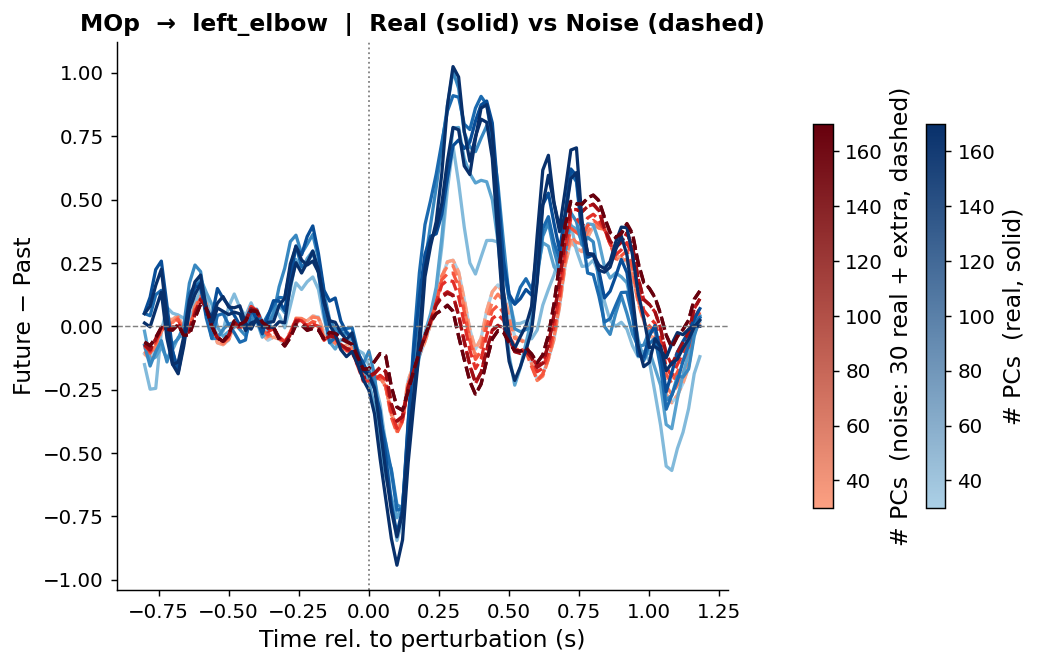

In [ ]:
## ── Dual sweep viz: future − past gap with gradient ──────────────────────────
_BASELINE_DS = (-1.0, -0.5)
_n_comps_ds  = np.array(sorted(results_real_sweep_ds.keys()))
_all_t_ds    = np.array(sorted(next(iter(results_real_sweep_ds.values())).keys()))
_t0_ds       = int(np.argmin(np.abs(_lags_bins_ds)))
_t_center_ds = _all_t_ds - WINDOW_S

# Two colormaps: Blues for real, Reds for noise
_cmap_real  = mpl.colormaps['Blues'].resampled(len(_n_comps_ds) + 2)
_cmap_noise = mpl.colormaps['Reds'].resampled(len(_n_comps_ds) + 2)
_norm_ds    = mpl.colors.Normalize(vmin=_n_comps_ds[0], vmax=_n_comps_ds[-1])

def _gap_curve(res_dict, nc, all_t, bl_s, t0):
    res     = res_dict[nc]
    bl_mask = (all_t >= bl_s[0]) & (all_t < bl_s[1])
    bl      = np.array([res[t].mean(-1) for t in all_t[bl_mask]]).mean(0)
    future  = np.array([np.sum(np.abs(res[t].mean(-1)[t0:] - bl[t0:])) for t in all_t])
    past    = np.array([np.sum(np.abs(res[t].mean(-1)[:t0] - bl[:t0])) for t in all_t])
    return future, past, future - past

PRES_RC_DS = {
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 12, "axes.labelsize": 13, "axes.titlesize": 13,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "figure.dpi": 130,
}

with mpl.rc_context(PRES_RC_DS):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    ax_real  = axes[0]   # left:  real PCs future & past
    ax_noise = axes[1]   # middle: noise PCs future & past
    ax_gap   = axes[2]   # right:  future − past gap

    for i, nc in enumerate(_n_comps_ds):
        frac    = i / max(len(_n_comps_ds) - 1, 1)
        c_real  = _cmap_real(0.35 + 0.65 * frac)
        c_noise = _cmap_noise(0.35 + 0.65 * frac)

        fut_r, pas_r, gap_r = _gap_curve(results_real_sweep_ds,  nc, _all_t_ds, _BASELINE_DS, _t0_ds)
        fut_n, pas_n, gap_n = _gap_curve(results_noise_sweep_ds, nc, _all_t_ds, _BASELINE_DS, _t0_ds)

        # Left panel: real condition future (solid) & past (dashed)
        ax_real.plot(_t_center_ds, fut_r, lw=1.8, color=c_real, ls='-')
        ax_real.plot(_t_center_ds, pas_r, lw=1.8, color=c_real, ls='--')

        # Middle panel: noise condition future (solid) & past (dashed)
        ax_noise.plot(_t_center_ds, fut_n, lw=1.8, color=c_noise, ls='-')
        ax_noise.plot(_t_center_ds, pas_n, lw=1.8, color=c_noise, ls='--')

        # Right panel: future − past gap
        ax_gap.plot(_t_center_ds, gap_r, lw=1.8, color=c_real)
        ax_gap.plot(_t_center_ds, gap_n, lw=1.8, color=c_noise, ls='--')

    for ax in axes:
        ax.axvline(0, color='gray', lw=1.0, ls=':')
        ax.set_xlabel('Time rel. to perturbation (s)')

    ax_real.axhline(0, color='gray', lw=0.8, ls='--')
    ax_real.set_ylabel('ΣΔR²')
    ax_real.set_title('Real PCs  |  future (solid) & past (dashed)')
    # legend proxies
    from matplotlib.lines import Line2D
    ax_real.legend(handles=[Line2D([0],[0], color='k', ls='-', lw=1.5, label='future'),
                             Line2D([0],[0], color='k', ls='--', lw=1.5, label='past')],
                   frameon=False, fontsize=10)

    ax_noise.axhline(0, color='gray', lw=0.8, ls='--')
    ax_noise.set_ylabel('ΣΔR²')
    ax_noise.set_title(f'Noise PCs ({N_REAL_COMP} real + extra)  |  future (solid) & past (dashed)')
    ax_noise.legend(handles=[Line2D([0],[0], color='k', ls='-', lw=1.5, label='future'),
                              Line2D([0],[0], color='k', ls='--', lw=1.5, label='past')],
                    frameon=False, fontsize=10)

    ax_gap.axhline(0, color='gray', lw=0.8, ls='--')
    ax_gap.set_ylabel('Future − Past  ΣΔR²')
    ax_gap.set_title('Future − Past asymmetry  |  real (solid) vs noise (dashed)')

    # Shared colourbars
    sm_r = mpl.cm.ScalarMappable(
        cmap=mpl.colors.LinearSegmentedColormap.from_list('bl_sub', [_cmap_real(0.35), _cmap_real(1.0)]),
        norm=_norm_ds)
    sm_n = mpl.cm.ScalarMappable(
        cmap=mpl.colors.LinearSegmentedColormap.from_list('rd_sub', [_cmap_noise(0.35), _cmap_noise(1.0)]),
        norm=_norm_ds)
    fig.colorbar(sm_r, ax=axes, location='right', pad=0.01, shrink=0.6, label='# PCs  (real, Blues)')
    fig.colorbar(sm_n, ax=axes, location='right', pad=0.06, shrink=0.6, label='# PCs  (noise, Reds)')

    fig.suptitle(f'{AREA}  →  {KEYPOINT}  |  Dual sweep: real vs noise', fontweight='bold')
    plt.show()
